# Sowing Success: How Machine Learning Helps Farmers Select the Best Crops


![Farmer in a field](farmer_in_a_field.jpg)

## Project Description and Objectives:

This project aims to assist farmers in selecting the most suitable crop for their fields based on essential soil metrics such as nitrogen, phosphorus, potassium levels, and pH value. Given the high costs and time associated with measuring these metrics, farmers often need to prioritize which measurements to take based on their budgets. Utilizing a dataset `soil_measures.csv` containing soil metrics and associated crop types, the project will employ machine learning techniques to develop multi-class classification models. These models will predict the type of crop that can thrive in a particular soil condition, ensuring optimal growth and maximum yield.

The following are the objectives of the project:

- **Assess Soil Condition:** Measure essential soil metrics (N, P, K, pH) to evaluate soil quality and its suitability for various crops.
- **Crop Prediction Model:** Develop machine learning models to accurately predict the best crop for a given set of soil conditions based on the historical data provided in the dataset.
- **Feature Importance Analysis:** Identify the single most important feature influencing crop selection, allowing farmers to focus on the most critical soil metric for their decisions.
- **Support Sustainable Farming Decisions:** Facilitate informed decision-making for farmers to maximize crop yield while considering budget constraints and soil health.

#### Importing required library

In [14]:

import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

#### Load the dataset

In [17]:
crops_df = pd.read_csv('soil_measures.csv')

In [19]:
crops_df.head()

,N,P,K,ph,crop
0,90,42,43,6.502985,rice
1,85,58,41,7.038096,rice
2,60,55,44,7.840207,rice
3,74,35,40,6.980401,rice
4,78,42,42,7.628473,rice


In [21]:
crops_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   N       2200 non-null   int64  
 1   P       2200 non-null   int64  
 2   K       2200 non-null   int64  
 3   ph      2200 non-null   float64
 4   crop    2200 non-null   object 
dtypes: float64(1), int64(3), object(1)
memory usage: 86.1+ KB


In [23]:
crops_df.describe()

,N,P,K,ph
count,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,6.469480
std,36.917334,32.985883,50.647931,0.773938
min,0.000000,5.000000,5.000000,3.504752
25%,21.000000,28.000000,20.000000,5.971693
50%,37.000000,51.000000,32.000000,6.425045
75%,84.250000,68.000000,49.000000,6.923643
max,140.000000,145.000000,205.000000,9.935091


#### Exploring the dataset

<Axes: >

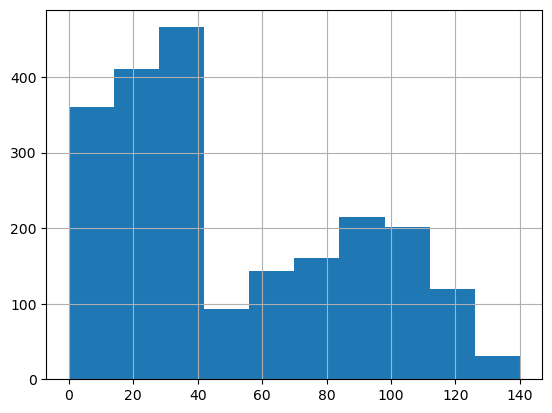

In [26]:
crops_df["N"].hist()

<Axes: >

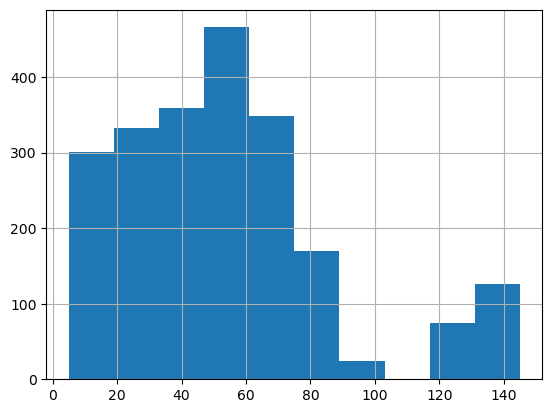

In [28]:
crops_df["P"].hist()

<Axes: >

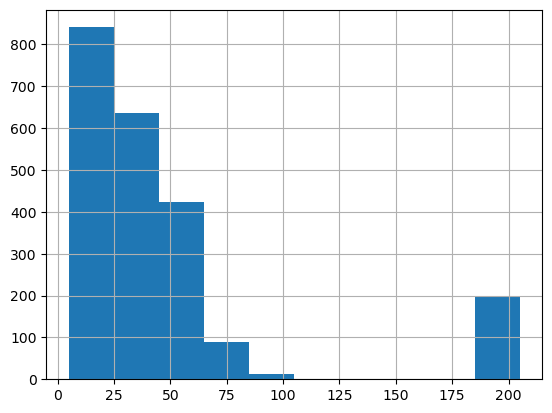

In [30]:
crops_df["K"].hist()

<Axes: >

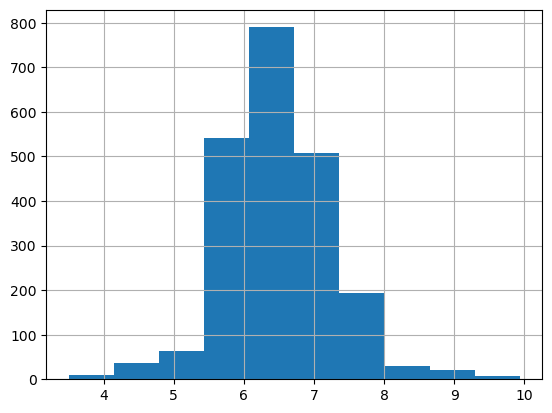

In [32]:
crops_df["ph"].hist()

In [34]:
crops_df.columns

Index(['N', 'P', 'K', 'ph', 'crop'], dtype='object')

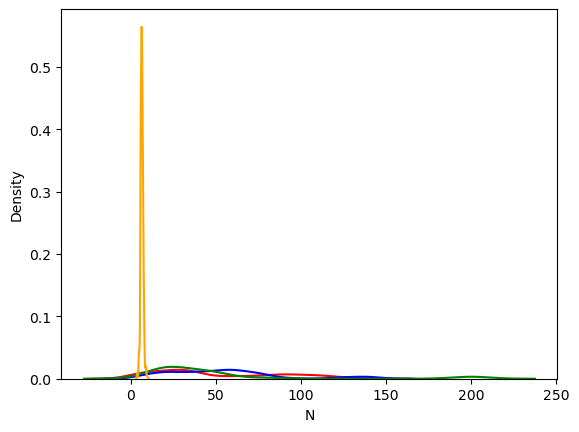

In [36]:
sns.kdeplot(crops_df["N"], label="Nitrogen", color="Red")
sns.kdeplot(crops_df["P"], label="Phosphorus", color="Blue")
sns.kdeplot(crops_df["K"], label="Potassium", color="Green")
sns.kdeplot(crops_df["ph"], label="ph level", color="Orange")

plt.show()

##### Insights Derived: 

- The Soil Nutrients (features) data is not normally distributed.
- Furthermore, There is an obvious need to standardize the features to avoid bias during modelling.

#### Extract the features data and the response data for modelling

In [40]:
X = crops_df.drop("crop", axis=1)
y = crops_df["crop"].values

In [42]:
np.unique(y)

array(['apple', 'banana', 'blackgram', 'chickpea', 'coconut', 'coffee',
       'cotton', 'grapes', 'jute', 'kidneybeans', 'lentil', 'maize',
       'mango', 'mothbeans', 'mungbean', 'muskmelon', 'orange', 'papaya',
       'pigeonpeas', 'pomegranate', 'rice', 'watermelon'], dtype=object)

In [44]:
len(np.unique(y))

22

#### Create the training and test sets using all features and response variables

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state=41)

#### Scale the Features test and training dataset

In [50]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [52]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [54]:
#convert back to a dataframe and assign column names
column_names = X.columns
X_train_df = pd.DataFrame(X_train_scaled, columns=column_names)
X_test_df = pd.DataFrame(X_test_scaled, columns=column_names)

In [56]:
X_train_df.head()

,N,P,K,ph
0,0.161480,0.124755,0.019253,0.061781
1,-0.356034,0.558788,-0.628824,1.130718
2,-1.173160,-0.991332,-0.244028,-0.906060
3,0.733468,-0.464291,-0.223776,-0.659146
4,1.550595,-0.309279,-0.588319,0.373794


In [58]:
X_test_df.head()

,N,P,K,ph
0,-0.846310,-1.177347,-0.264281,-1.009100
1,-1.173160,-1.146344,-0.770591,1.769218
2,1.904683,-1.425366,-0.000999,0.254677
3,-0.356034,0.589791,-0.588319,-0.959027
4,-0.410509,2.511940,3.178628,-0.806409


#### Plotting the density plots of the scaled features datasets

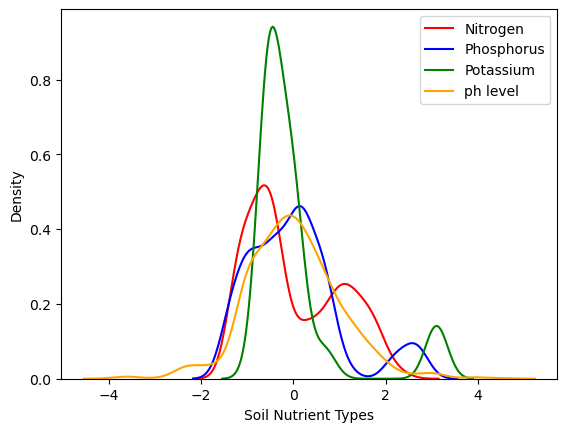

In [61]:
sns.kdeplot(X_train_df["N"], label="Nitrogen", color="Red")
sns.kdeplot(X_train_df["P"], label="Phosphorus", color="Blue")
sns.kdeplot(X_train_df["K"], label="Potassium", color="Green")
sns.kdeplot(X_train_df["ph"], label="ph level", color="Orange")

plt.xlabel("Soil Nutrient Types")
plt.legend()
plt.show()

#### Assessing the normality of the dataset

In [64]:
from scipy.stats import shapiro

stat, p_value= shapiro(X_train_df["N"])
p_value

2.0772232970985196e-28

In [66]:
stat, p_value = shapiro(X_train_df["P"])
p_value

5.956149603458302e-29

In [68]:
stat, p_value = shapiro(X_train_df["K"])
p_value

0.0

In [175]:
stat, p_value = shapiro(X_train_df["ph"])
p_value

7.38766957764786e-13

##### Insights Derived: 

- The Shapiro tests for all the soil nutients return a p_value of less that 0.05, thus, the Soil Nutrients (features) data is not normally distributed.


#### Develop machine learning models for each soil nutrient (N, K, P, ph) to accurately predict the best crop

- To decide on a predictive supervised learning model for the best crop, we factor in the following:
    - The response variable is categorical with more than two (twenty-two) categories
    - The features dataset is numeric and not normally distributed
    - The dataset contains slightly over 2000 rows

##### Two Supervised ML models will be used:
- Decision Tree Classifier
- Logistic (Multinomial) Regression Model 

In [80]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

models = {"Logistic Regression": LogisticRegression(multi_class="multinomial"),
          "Decision Tree":DecisionTreeClassifier()}

cross_val_results = []

#### Evaluating the performance of the models using Cross-validation of training data

In [101]:
cross_val_results = []

for model in models.values():
    kf = KFold(n_splits=5, random_state=42, shuffle=True)
    cv_results = cross_val_score(model, X_train_scaled, y_train, cv=kf)
    cross_val_results.append(cv_results)


{'whiskers': [<matplotlib.lines.Line2D at 0x1977ae435d0>,
 'caps': [<matplotlib.lines.Line2D at 0x1977bb8a790>,
 'boxes': [<matplotlib.lines.Line2D at 0x1977bb8e190>,
 'medians': [<matplotlib.lines.Line2D at 0x1977bb89f90>,
 'fliers': [<matplotlib.lines.Line2D at 0x1977bb8aad0>,
 'means': []}

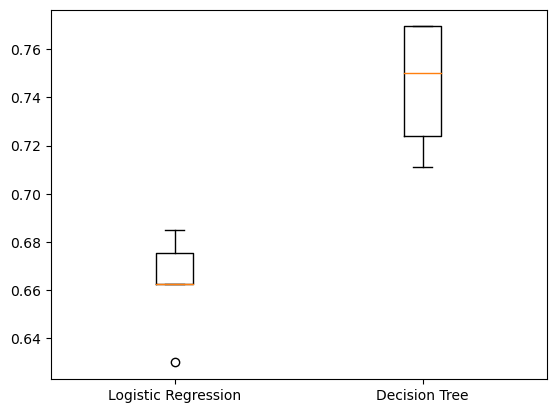

In [78]:
plt.boxplot(cross_val_results, labels=models.keys())

##### Insights derived:
- The Decision Tree Model performs better from the results because it has a higher median of scores than the Logistic Regression model.
- Although it is more variable across the folds, which could indicate that it adapts better to different data splits but is also more sensitive to variations in the data.
- Logistic Regression: A tightly clustered boxplot (with the 25th and 50th percentiles being the same) suggests consistent performance across the lower performing folds, but it might lack variability or adaptability to diverse data patterns.

#### Evaluating the performance of the models using Accuarcy score of the test dataset

In [87]:
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    test_score = model.score(X_test_scaled, y_test)
    print(f"{name} Test Set Accuracy: {test_score:.2f}")

Logistic Regression Test Set Accuracy: 0.68
Decision Tree Test Set Accuracy: 0.79


##### Insights derived:
- The Decision Tree performs better from the results becaise it has a higher Accuracy result

#### Hypothesis test to evaluate the statistical significance of the cross-validation results of the two models

- **Null Hypothesis**: There is no difference between the Decision Tree and the Logistic Regression results
- **Alternate Hypothesis**: The Decision Tree results are greater than the Logistic Regression results

In [115]:
Log_reg_results = cross_val_results[0]
Dec_tree_results = cross_val_results[1]

- The result dataset is too small for parametric tests, wo we use a non-parametric test that is suitable for two groups evaluation: **Wilcoxon Mann Whitney U Test**

In [121]:
from scipy.stats import mannwhitneyu

results = mannwhitneyu(x=Dec_tree_results, y=Log_reg_results, alternative="greater")
results

MannwhitneyuResult(statistic=25.0, pvalue=0.005833656171659693)

##### Insights derived:
- Based on a 5% significance level, we reject the null hypothesis in favor of the alternative hypothesis, due to a p_value of 0.0058
- The Decision Tree Model performs better in terms of accuracy than the Logistic Regression model.

#### Fitting the Decision Tree Classifier Model on the Training Dataset to predict unseen data

In [130]:
features = X_train_df.columns
features

Index(['N', 'P', 'K', 'ph'], dtype='object')

In [141]:
from sklearn.metrics import f1_score

features_performance = {}

for feature in features:
    dec_tree = DecisionTreeClassifier()
    dec_tree.fit(X_train_df[[feature]], y_train)
    y_pred = dec_tree.predict(X_test_df[[feature]])
    feature_f1_score = f1_score(y_pred, y_test, average="weighted")
    features_performance[feature] = feature_f1_score
    print(f"F1-score for {feature}: {features_performance[feature]:.2f}")

F1-score for N: 0.19
F1-score for P: 0.19
F1-score for K: 0.31
F1-score for ph: 0.13


In [139]:
features_performance

{'N': 0.1918949270171624,
 'P': 0.1880756680813984,
 'K': 0.31336144270903665,
 'ph': 0.12963799589023225}

##### Insights derived:
- From the performance results, it is apparent the the most important predictive feature is **"K"**, since it has the highest f1_score.
- Thus farmers can focus their budgets on simply testing for the Potassium levels of their soil to predict what crop types to be planted.